# 1. Title and Step 3 objective

Estimate the dense periodic n=1 event weight with one parametric and one non-parametric observable method. This notebook stops after held-out event-weight estimation accuracy; it does not perform Step 4.


## 2. Model identity and the observability limitation

For n=1, sigma_next = sqrt(omega_next) F_i, so omega_next = (sigma_next / F_i)^2. The hidden eta_i shock prevents exact transition-level recovery from observables: the methods below estimate an observable conditional event-free baseline, making raw multiplier proxies noisy. Repeated periodic cycles instead allow an event-age weight profile to be pooled.


## 3. Load the dense periodic n = 1 simulation


In [1]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import optimize, stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.precision', 6)
model_params = reference_config['model']
event_params = reference_config['events']
simulation_params = reference_config['simulation']
steps_per_year = reference_timing['steps_per_year']
event_period_steps = reference_timing['event_period_steps']
response_horizon_steps = reference_timing['response_horizon_steps']
event_transition_ages = list(reference_timing['event_transition_ages'])
event_ages = event_transition_ages
assert model_params['n'] == 1
if reference_timing['event_responses_overlap']:
    raise ValueError(
        "Notebook 03's single-event-age estimator requires "
        "non-overlapping event responses. Overlapping responses need a "
        "multi-event weight decomposition."
    )
n_steps = simulation_params['years'] * steps_per_year
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
dense_result = simulate_event_volatility(
    time_grid=time_grid, S0=simulation_params['S0'], sigma0=simulation_params['sigma0'],
    n=model_params['n'], alpha_fn=alpha_fn, nu_fn=nu_fn, rho_fn=rho_fn,
    event_weight_fn=event_weight_fn, model_params=model_params, event_times=event_times,
    event_params=event_params, seed=simulation_params['seed'],
)
states = dense_result['states'].copy()
transitions = dense_result['transitions'].copy()
pd.testing.assert_frame_equal(states, reference_result['states'])
pd.testing.assert_frame_equal(transitions, reference_result['transitions'])
assert len(event_times) == int(transitions['event'].sum())
print(f"Regenerated {len(transitions)} transitions using reference seed {simulation_params['seed']}.")


Regenerated 504 transitions using reference seed 20260721.


## 4. Build the event-history and event-age table


In [3]:
analysis_table = pd.DataFrame({
    'i': transitions['i'].to_numpy(), 'target_i': transitions['target_i'].to_numpy(),
    't_i': transitions['t'].to_numpy(), 'dt_i': transitions['dt'].to_numpy(),
    'S_i': states['S'].iloc[:-1].to_numpy(), 'S_next': states['S'].iloc[1:].to_numpy(),
    'sigma_i': states['sigma'].iloc[:-1].to_numpy(), 'sigma_next': states['sigma'].iloc[1:].to_numpy(),
    'event_i': transitions['event'].to_numpy(dtype=int),
})
analysis_table['simple_return_i'] = (analysis_table['S_next'] - analysis_table['S_i']) / analysis_table['S_i']
analysis_table['epsilon_proxy_i'] = analysis_table['simple_return_i'] / analysis_table['sigma_i']
event_features = [f'event_lag_{age}' for age in event_transition_ages]
for lag, feature in enumerate(event_features):
    analysis_table[feature] = analysis_table['event_i'].shift(lag)
analysis_table = analysis_table.dropna(subset=event_features).copy().reset_index(drop=True)
analysis_table[event_features] = analysis_table[event_features].astype(int)
analysis_table['event_active_i'] = analysis_table[event_features].sum(axis=1).gt(0).astype(int)
analysis_table['event_age_i'] = np.where(
    analysis_table['event_active_i'].eq(1),
    analysis_table[event_features].to_numpy().argmax(axis=1),
    np.nan,
)
analysis_table['event_age_years_i'] = analysis_table['event_age_i'] / steps_per_year

assert len(analysis_table) == len(transitions) - response_horizon_steps
for lag, feature in enumerate(event_features):
    np.testing.assert_array_equal(analysis_table[feature], transitions['event'].shift(lag).iloc[response_horizon_steps:].to_numpy(dtype=int))
active_lag_count = analysis_table[event_features].sum(axis=1)
assert active_lag_count.loc[analysis_table['event_active_i'].eq(1)].eq(1).all()
assert active_lag_count.loc[analysis_table['event_active_i'].eq(0)].eq(0).all()
assert set(analysis_table.loc[analysis_table['event_active_i'].eq(1), 'event_age_i'].unique()) == set(event_transition_ages)
observable_columns = ['S_i', 'S_next', 'sigma_i', 'sigma_next', 'simple_return_i', 'epsilon_proxy_i', *event_features]
assert np.isfinite(analysis_table[observable_columns].to_numpy(dtype=float)).all()
np.testing.assert_allclose(analysis_table['epsilon_proxy_i'], transitions['epsilon'].iloc[response_horizon_steps:], rtol=0.0, atol=1e-12)
baseline_feature_columns = ['sigma_i', 'epsilon_proxy_i']
hidden_feature_names = {'eta', 'F', 'omega_next', 'event_multiplier', 'alpha', 'nu', 'rho', 'epsilon', 'correlated_shock'}
assert set(baseline_feature_columns).isdisjoint(hidden_feature_names)
print(f'Usable rows: {len(analysis_table)}; active rows: {int(analysis_table['event_active_i'].sum())}.')
analysis_table.head()


Usable rows: 492; active rows: 299.


,i,target_i,t_i,dt_i,S_i,S_next,sigma_i,sigma_next,event_i,simple_return_i,...,event_lag_6,event_lag_7,event_lag_8,event_lag_9,event_lag_10,event_lag_11,event_lag_12,event_active_i,event_age_i,event_age_years_i
0,12,13,0.047619,0.003968,102.751010,102.087857,0.195601,0.195878,0,-0.006454,...,0,0,0,0,0,0,0,0,NaN,NaN
1,13,14,0.051587,0.003968,102.087857,102.490211,0.195878,0.196371,0,0.003941,...,0,0,0,0,0,0,0,0,NaN,NaN
2,14,15,0.055556,0.003968,102.490211,101.771270,0.196371,0.195697,0,-0.007015,...,0,0,0,0,0,0,0,0,NaN,NaN
3,15,16,0.059524,0.003968,101.771270,100.296205,0.195697,0.195363,0,-0.014494,...,0,0,0,0,0,0,0,0,NaN,NaN
4,16,17,0.063492,0.003968,100.296205,100.888858,0.195363,0.194100,0,0.005909,...,0,0,0,0,0,0,0,0,NaN,NaN


## 5. Chronological train-test split

The approximately 70% split is moved forward to the next exact event so no event-response window is cut in half. Earlier rows form training; the event row and all later rows form testing.


In [4]:
approximate_split = int(np.floor(0.70 * len(analysis_table)))
candidate_positions = np.flatnonzero(analysis_table['event_lag_0'].to_numpy() == 1)
split_index = int(candidate_positions[candidate_positions >= approximate_split][0])
train_data = analysis_table.iloc[:split_index].copy()
test_data = analysis_table.iloc[split_index:].copy()
split_summary = pd.DataFrame([{
    'split_index': split_index,
    'training_date_range': f'{train_data['t_i'].iloc[0]:.6f} to {train_data['t_i'].iloc[-1]:.6f}',
    'testing_date_range': f'{test_data['t_i'].iloc[0]:.6f} to {test_data['t_i'].iloc[-1]:.6f}',
    'training_rows': len(train_data), 'testing_rows': len(test_data),
    'exact_training_events': int(train_data['event_i'].sum()), 'exact_testing_events': int(test_data['event_i'].sum()),
    'active_training_rows': int(train_data['event_active_i'].sum()), 'active_testing_rows': int(test_data['event_active_i'].sum()),
    'event_free_training_rows': int(train_data['event_active_i'].eq(0).sum()), 'event_free_testing_rows': int(test_data['event_active_i'].eq(0).sum()),
}])
assert train_data['t_i'].max() < test_data['t_i'].min()
assert test_data['event_lag_0'].iloc[0] == 1
assert set(train_data.loc[train_data['event_active_i'].eq(1), 'event_age_i'].astype(int)) == set(event_transition_ages)
assert set(test_data.loc[test_data['event_active_i'].eq(1), 'event_age_i'].astype(int)) == set(event_transition_ages)
display(split_summary)


,split_index,training_date_range,testing_date_range,training_rows,testing_rows,exact_training_events,exact_testing_events,active_training_rows,active_testing_rows,event_free_training_rows,event_free_testing_rows
0,345,0.047619 to 1.412698,1.416667 to 1.996032,345,147,16,7,208,91,137,56


## 6. Parametric event-free baseline

On event-free rows omega_next equals one and sigma_next equals the event-free baseline. The n=1 conditional mean is linear: E[F_i | sigma_i, epsilon_i] = kappa theta dt + (1-kappa dt) sigma_i + nu rho epsilon_i. The OLS fit does not use those known parameters.


In [5]:
event_free_train = train_data.loc[train_data['event_active_i'].eq(0)].copy()
event_free_test = test_data.loc[test_data['event_active_i'].eq(0)].copy()
ols_baseline = sm.OLS(
    event_free_train['sigma_next'], sm.add_constant(event_free_train[baseline_feature_columns], has_constant='add')
).fit()
analysis_table['F_hat_parametric'] = ols_baseline.predict(sm.add_constant(analysis_table[baseline_feature_columns], has_constant='add'))
if (analysis_table['F_hat_parametric'] <= 0).any():
    raise ValueError('Parametric observable event-free baseline has a non-positive prediction.')

def error_summary(observed, predicted):
    error = np.asarray(predicted) - np.asarray(observed)
    return {'RMSE': float(np.sqrt(mean_squared_error(observed, predicted))), 'MAE': float(mean_absolute_error(observed, predicted)), 'bias': float(error.mean())}

parametric_baseline_test = error_summary(event_free_test['sigma_next'], analysis_table.loc[event_free_test.index, 'F_hat_parametric'])
coefficient_ci = ols_baseline.conf_int()
ols_coefficient_table = pd.DataFrame({
    'estimate': ols_baseline.params, 'standard_error': ols_baseline.bse,
    'CI_low': coefficient_ci[0], 'CI_high': coefficient_ci[1],
})
theoretical_coefficients = pd.Series({
    'const': model_params['kappa'] * model_params['theta'] / steps_per_year,
    'sigma_i': 1 - model_params['kappa'] / steps_per_year,
    'epsilon_proxy_i': model_params['nu_0'] * model_params['rho_0'],
}, name='theoretical_conditional_mean')
display(ols_coefficient_table.join(theoretical_coefficients))
print(f'Event-free training R-squared: {ols_baseline.rsquared:.6f}')
print('Event-free test:', parametric_baseline_test)


,estimate,standard_error,CI_low,CI_high,theoretical_conditional_mean
const,0.001754,0.001263,-0.000745,0.004253,0.001190
sigma_i,0.991565,0.005614,0.980460,1.002669,0.994048
epsilon_proxy_i,-0.007568,0.001106,-0.009755,-0.005381,-0.005250


Event-free training R-squared: 0.995734
Event-free test: {'RMSE': 0.0008226959004143442, 'MAE': 0.000633268011933568, 'bias': -6.127353377607203e-05}


## 7. Non-parametric event-free baseline

The fixed random forest uses the same observable baseline features and event-free training rows only. It is not tuned. Random forests cannot extrapolate smoothly outside their observed training support.


In [6]:
rf_baseline = RandomForestRegressor(
    n_estimators=300, max_depth=6, min_samples_leaf=3, max_features=1.0,
    random_state=20260725, n_jobs=-1,
)
rf_baseline.fit(event_free_train[baseline_feature_columns], event_free_train['sigma_next'])
analysis_table['F_hat_nonparametric'] = rf_baseline.predict(analysis_table[baseline_feature_columns])
if (analysis_table['F_hat_nonparametric'] <= 0).any():
    raise ValueError('Non-parametric observable event-free baseline has a non-positive prediction.')
rf_train_metrics = error_summary(event_free_train['sigma_next'], analysis_table.loc[event_free_train.index, 'F_hat_nonparametric'])
rf_test_metrics = error_summary(event_free_test['sigma_next'], analysis_table.loc[event_free_test.index, 'F_hat_nonparametric'])
support_rows = []
for feature in baseline_feature_columns:
    lower, upper = event_free_train[feature].min(), event_free_train[feature].max()
    active_test_values = test_data.loc[test_data['event_active_i'].eq(1), feature]
    support_rows.append({'feature': feature, 'event_free_train_min': lower, 'event_free_train_max': upper, 'active_test_out_of_range_fraction': float(((active_test_values < lower) | (active_test_values > upper)).mean())})
support_diagnostic = pd.DataFrame(support_rows)
print('Event-free training:', rf_train_metrics)
print('Event-free test:', rf_test_metrics)
display(support_diagnostic)


Event-free training: {'RMSE': 0.0007511442972827246, 'MAE': 0.0006197219391446297, 'bias': 2.067505622945743e-06}
Event-free test: {'RMSE': 0.011992210794957235, 'MAE': 0.010778597227887246, 'bias': -0.010740906059720352}


,feature,event_free_train_min,event_free_train_max,active_test_out_of_range_fraction
0,sigma_i,0.19410,0.243689,0.934066
1,epsilon_proxy_i,-0.19511,0.166888,0.000000


## 8. Baseline diagnostics


In [7]:
baseline_diagnostics = pd.DataFrame([
    {'method': 'parametric OLS', 'training_RMSE': error_summary(event_free_train['sigma_next'], analysis_table.loc[event_free_train.index, 'F_hat_parametric'])['RMSE'], 'training_MAE': error_summary(event_free_train['sigma_next'], analysis_table.loc[event_free_train.index, 'F_hat_parametric'])['MAE'], 'test_RMSE': parametric_baseline_test['RMSE'], 'test_MAE': parametric_baseline_test['MAE'], 'test_bias': parametric_baseline_test['bias']},
    {'method': 'non-parametric RF', 'training_RMSE': rf_train_metrics['RMSE'], 'training_MAE': rf_train_metrics['MAE'], 'test_RMSE': rf_test_metrics['RMSE'], 'test_MAE': rf_test_metrics['MAE'], 'test_bias': rf_test_metrics['bias']},
])
display(baseline_diagnostics)


,method,training_RMSE,training_MAE,test_RMSE,test_MAE,test_bias
0,parametric OLS,0.000893,0.000751,0.000823,0.000633,-0.000061
1,non-parametric RF,0.000751,0.000620,0.011992,0.010779,-0.010741


## 9. Raw multiplier and raw weight proxies

Raw proxies are diagnostics, not final profiles. Unobserved eta_i leaves irreducible hidden-shock noise even on event-free rows, so they are not forced or clipped toward one.


In [8]:
training_proxy = analysis_table.loc[train_data.index].copy()
for method in ['parametric', 'nonparametric']:
    training_proxy[f'm_raw_{method}'] = training_proxy['sigma_next'] / training_proxy[f'F_hat_{method}']
    training_proxy[f'omega_raw_{method}'] = training_proxy[f'm_raw_{method}'] ** 2
event_free_proxy_summary = []
for method in ['parametric', 'nonparametric']:
    subset = training_proxy.loc[training_proxy['event_active_i'].eq(0)]
    event_free_proxy_summary.append({
        'method': method, 'mean_raw_multiplier': subset[f'm_raw_{method}'].mean(), 'std_raw_multiplier': subset[f'm_raw_{method}'].std(), 'median_raw_multiplier': subset[f'm_raw_{method}'].median(),
        'mean_raw_omega': subset[f'omega_raw_{method}'].mean(), 'std_raw_omega': subset[f'omega_raw_{method}'].std(), 'median_raw_omega': subset[f'omega_raw_{method}'].median(),
    })
event_free_proxy_summary = pd.DataFrame(event_free_proxy_summary)
assert (training_proxy[['m_raw_parametric', 'm_raw_nonparametric', 'omega_raw_parametric', 'omega_raw_nonparametric']] > 0).all().all()
display(event_free_proxy_summary)


,method,mean_raw_multiplier,std_raw_multiplier,median_raw_multiplier,mean_raw_omega,std_raw_omega,median_raw_omega
0,parametric,1.000001,0.004025,0.999860,1.000018,0.008053,0.999719
1,nonparametric,0.999979,0.003374,0.999962,0.999970,0.006751,0.999924


## 10. Parametric exponential event-weight estimator

The parametric exponential estimate pools active training raw multiplier proxies with m(a)=sqrt(1+A exp(-lambda a)). Initial values come only from observed raw proxies; both fitted parameters are constrained non-negative.


In [9]:
active_train_proxy = training_proxy.loc[training_proxy['event_active_i'].eq(1)].copy()
age_zero_multiplier = active_train_proxy.loc[active_train_proxy['event_age_i'].eq(0), 'm_raw_parametric'].mean()
initial_amplitude = max(float(age_zero_multiplier ** 2 - 1.0), 1e-4)
initial_decay = 10.0
parametric_initialisation_uses_true_parameters = False
def exponential_multiplier(age_years, amplitude, decay_rate):
    return np.sqrt(1.0 + amplitude * np.exp(-decay_rate * np.asarray(age_years)))

def multiplier_residuals(parameters, ages, observed_multiplier):
    return exponential_multiplier(ages, parameters[0], parameters[1]) - observed_multiplier

parametric_fit = optimize.least_squares(
    multiplier_residuals, x0=np.array([initial_amplitude, initial_decay]), bounds=(0.0, np.inf),
    args=(active_train_proxy['event_age_years_i'].to_numpy(), active_train_proxy['m_raw_parametric'].to_numpy()),
)
A_hat, lambda_hat = map(float, parametric_fit.x)
parametric_objective = float(2.0 * parametric_fit.cost)
analysis_table['omega_hat_parametric'] = 1.0
active_mask = analysis_table['event_active_i'].eq(1)
analysis_table.loc[active_mask, 'omega_hat_parametric'] = 1.0 + A_hat * np.exp(-lambda_hat * analysis_table.loc[active_mask, 'event_age_years_i'])
assert parametric_fit.success and A_hat >= 0 and lambda_hat >= 0
parametric_fit_summary = pd.DataFrame([{
    'estimated_A': A_hat, 'estimated_lambda': lambda_hat, 'optimisation_success': parametric_fit.success,
    'objective_value': parametric_objective, 'active_training_observations': len(active_train_proxy),
}])
display(parametric_fit_summary)


,estimated_A,estimated_lambda,optimisation_success,objective_value,active_training_observations
0,0.008403,36.058112,True,0.00354,208


## 11. Non-parametric event-age estimator

The non-parametric cell-mean estimate makes no exponential or monotonicity assumption: it pools raw multipliers only among active training rows with the same event age. The median profile is reported only as a robustness diagnostic.


In [10]:
age_profile = active_train_proxy.groupby('event_age_i')['m_raw_nonparametric'].agg(['count', 'mean', 'std', 'median']).reindex(event_transition_ages)
age_profile['standard_error'] = age_profile['std'] / np.sqrt(age_profile['count'])
age_profile['omega_hat_nonparametric'] = age_profile['mean'] ** 2
age_profile['omega_median_diagnostic'] = age_profile['median'] ** 2
assert age_profile['count'].notna().all() and age_profile['count'].ge(1).all()
age_profile.index.name = 'event_age_i'
analysis_table['omega_hat_nonparametric'] = 1.0
analysis_table.loc[active_mask, 'omega_hat_nonparametric'] = analysis_table.loc[active_mask, 'event_age_i'].map(age_profile['omega_hat_nonparametric'])
estimators_fitted = True
assert analysis_table[['omega_hat_parametric', 'omega_hat_nonparametric']].gt(0).all().all()
display(age_profile)


,count,mean,std,median,standard_error,omega_hat_nonparametric,omega_median_diagnostic
event_age_i,,,,,,,
0,16,1.003706,0.005510,1.004052,0.001378,1.007426,1.008121
1,16,1.002728,0.004441,1.003205,0.001110,1.005463,1.006421
2,16,1.004128,0.004490,1.003833,0.001123,1.008273,1.007680
3,16,1.005145,0.005881,1.004880,0.001470,1.010316,1.009785
4,16,1.003255,0.006950,1.004674,0.001737,1.006520,1.009369
5,16,1.003098,0.004768,1.003775,0.001192,1.006205,1.007564
6,16,1.002845,0.006949,1.004148,0.001737,1.005698,1.008313
7,16,1.001601,0.005333,1.001815,0.001333,1.003205,1.003634
8,16,1.001647,0.006718,1.002462,0.001679,1.003298,1.004929


## 12. Synthetic ground-truth evaluation

Only now are synthetic truth and true event parameters accessed, for held-out weight-estimation accuracy. They are not fitting inputs and neither estimator is refitted after this comparison. Active-row results are primary because event-free profiles equal one by definition.


In [11]:
assert estimators_fitted
true_quantities_accessed_after_fit = True
analysis_table['true_omega_next'] = transitions.set_index('i').loc[analysis_table['i'], 'omega_next'].to_numpy()
true_amplitude = float(event_params['amplitude'])
true_decay_rate = float(event_params['decay_rate'])
test_evaluation = analysis_table.loc[test_data.index].copy()
active_test_evaluation = test_evaluation.loc[test_evaluation['event_active_i'].eq(1)].copy()

def weight_metrics(data, estimate_column):
    error = data[estimate_column] - data['true_omega_next']
    return {'MAE': float(error.abs().mean()), 'RMSE': float(np.sqrt(np.mean(error ** 2))), 'mean_error': float(error.mean()), 'max_abs_error': float(error.abs().max())}

metric_rows = []
for method, column in [('parametric', 'omega_hat_parametric'), ('non-parametric', 'omega_hat_nonparametric')]:
    all_metrics = weight_metrics(test_evaluation, column)
    active_metrics = weight_metrics(active_test_evaluation, column)
    active_metrics['Pearson_correlation'] = float(stats.pearsonr(active_test_evaluation[column], active_test_evaluation['true_omega_next']).statistic)
    metric_rows.append({'method': method, **{f'all_{k}': v for k, v in all_metrics.items()}, **{f'active_{k}': v for k, v in active_metrics.items()}})
weight_metric_table = pd.DataFrame(metric_rows)
true_age_profile = active_test_evaluation.groupby('event_age_i')['true_omega_next'].mean().reindex(event_transition_ages)
profile_error_rows = []
for method, column in [('parametric', 'omega_hat_parametric'), ('non-parametric', 'omega_hat_nonparametric')]:
    estimated_profile = active_test_evaluation.groupby('event_age_i')[column].mean().reindex(event_transition_ages)
    difference = estimated_profile - true_age_profile
    profile_error_rows.append({'method': method, 'age_profile_MAE': float(difference.abs().mean()), 'age_profile_RMSE': float(np.sqrt(np.mean(difference ** 2))), 'age_profile_max_abs_error': float(difference.abs().max())})
profile_error_table = pd.DataFrame(profile_error_rows)
parameter_comparison = pd.DataFrame([{
    'estimated_A': A_hat, 'true_A': true_amplitude, 'relative_amplitude_error': (A_hat - true_amplitude) / true_amplitude,
    'estimated_lambda': lambda_hat, 'true_lambda': true_decay_rate, 'relative_decay_error': (lambda_hat - true_decay_rate) / true_decay_rate,
}])
display(weight_metric_table)
display(profile_error_table)
display(parameter_comparison)


,method,all_MAE,all_RMSE,all_mean_error,all_max_abs_error,active_MAE,active_RMSE,active_mean_error,active_max_abs_error,active_Pearson_correlation
0,parametric,0.000534,0.000741,-0.000534,0.001597,0.000863,0.000942,-0.000863,0.001597,0.999979
1,non-parametric,0.000894,0.001454,-0.000130,0.003724,0.001444,0.001847,-0.000209,0.003724,0.790472


,method,age_profile_MAE,age_profile_RMSE,age_profile_max_abs_error
0,parametric,0.000863,0.000942,0.001597
1,non-parametric,0.001444,0.001847,0.003724


,estimated_A,true_A,relative_amplitude_error,estimated_lambda,true_lambda,relative_decay_error
0,0.008403,0.01,-0.159688,36.058112,35.0,0.030232


## 13. Exact simulation identity benchmark

Exact simulation identity check - not an observable estimator. This hidden-F benchmark is used only after fitting to verify the simulator algebra. The event-calendar profile below is likewise synthetic evaluation only, not an implementable real-data method.


In [12]:
hidden_transition_view = transitions.set_index('i').loc[analysis_table['i']]
hidden_identity_weight = (analysis_table['sigma_next'].to_numpy() / hidden_transition_view['F'].to_numpy()) ** 2
np.testing.assert_allclose(hidden_identity_weight, analysis_table['true_omega_next'].to_numpy(), rtol=0.0, atol=1e-12)
calendar_benchmark_profile = true_age_profile.rename('true_event_calendar_weight').to_frame()
exact_hidden_identity_used_after_fit = estimators_fitted
print('Exact simulation identity check - not an observable estimator: passed.')
display(calendar_benchmark_profile)


Exact simulation identity check - not an observable estimator: passed.


,true_event_calendar_weight
event_age_i,
0,1.010000
1,1.008703
2,1.007575
3,1.006592
4,1.005738
5,1.004994
6,1.004346
7,1.003782
8,1.003292


## 14. Event-weight plots


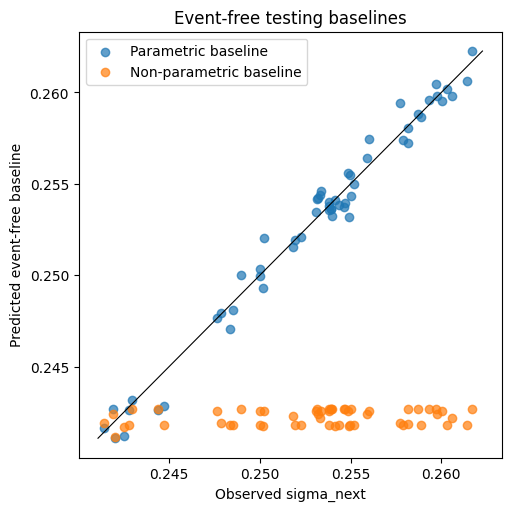

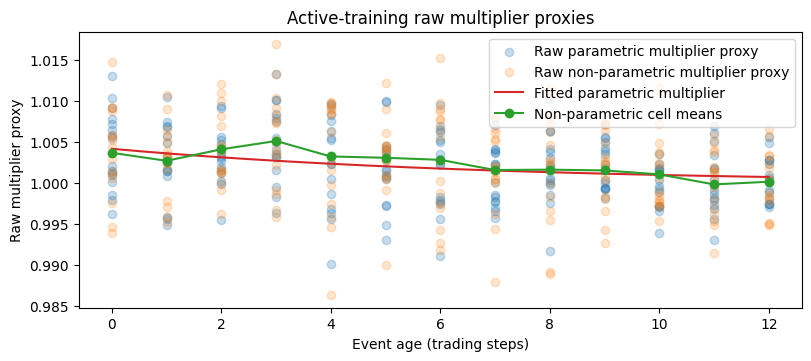

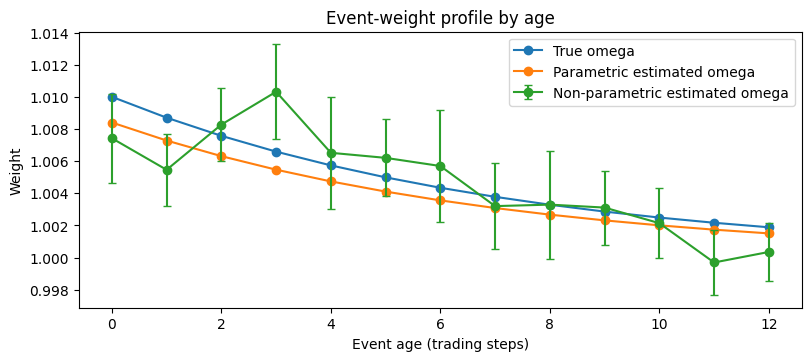

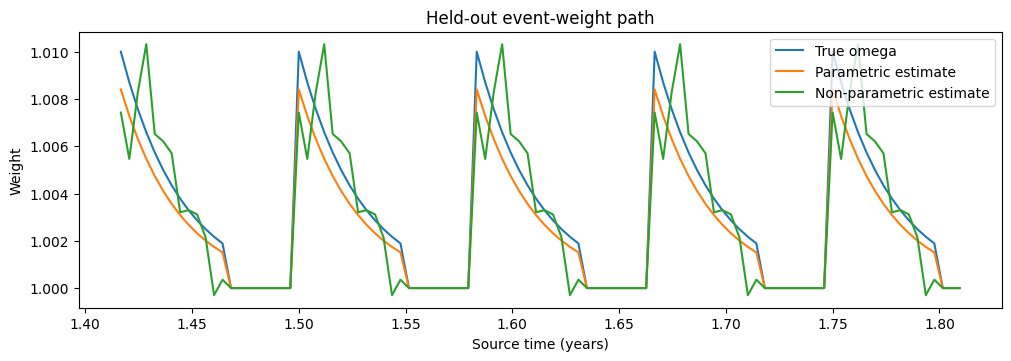

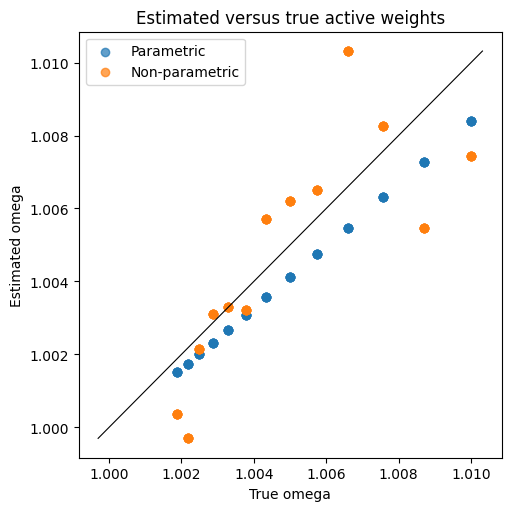

In [13]:
event_free_test_plot = analysis_table.loc[event_free_test.index]
fig, axis = plt.subplots(figsize=(5, 5), constrained_layout=True)
axis.scatter(event_free_test_plot['sigma_next'], event_free_test_plot['F_hat_parametric'], alpha=0.7, label='Parametric baseline')
axis.scatter(event_free_test_plot['sigma_next'], event_free_test_plot['F_hat_nonparametric'], alpha=0.7, label='Non-parametric baseline')
limits = [event_free_test_plot[['sigma_next', 'F_hat_parametric', 'F_hat_nonparametric']].min().min(), event_free_test_plot[['sigma_next', 'F_hat_parametric', 'F_hat_nonparametric']].max().max()]
axis.plot(limits, limits, color='black', linewidth=0.8)
axis.set(title='Event-free testing baselines', xlabel='Observed sigma_next', ylabel='Predicted event-free baseline')
axis.legend()
plt.show()

fig, axis = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
axis.scatter(active_train_proxy['event_age_i'], active_train_proxy['m_raw_parametric'], alpha=0.25, label='Raw parametric multiplier proxy')
axis.scatter(active_train_proxy['event_age_i'], active_train_proxy['m_raw_nonparametric'], alpha=0.20, label='Raw non-parametric multiplier proxy')
age_grid = np.linspace(min(event_transition_ages), max(event_transition_ages), 200)
axis.plot(age_grid, exponential_multiplier(age_grid / steps_per_year, A_hat, lambda_hat), color='tab:red', label='Fitted parametric multiplier')
axis.plot(age_profile.index, age_profile['mean'], marker='o', color='tab:green', label='Non-parametric cell means')
axis.set(title='Active-training raw multiplier proxies', xlabel='Event age (trading steps)', ylabel='Raw multiplier proxy')
axis.legend()
plt.show()

parametric_profile = 1.0 + A_hat * np.exp(-lambda_hat * np.asarray(event_transition_ages) / steps_per_year)
fig, axis = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
axis.plot(event_transition_ages, true_age_profile, marker='o', label='True omega')
axis.plot(event_transition_ages, parametric_profile, marker='o', label='Parametric estimated omega')
axis.errorbar(age_profile.index, age_profile['omega_hat_nonparametric'], yerr=2 * age_profile['mean'] * age_profile['standard_error'], fmt='o-', capsize=3, label='Non-parametric estimated omega')
axis.set(title='Event-weight profile by age', xlabel='Event age (trading steps)', ylabel='Weight')
axis.legend()
plt.show()

path_view = test_evaluation.iloc[:min(100, len(test_evaluation))]
fig, axis = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
axis.plot(path_view['t_i'], path_view['true_omega_next'], label='True omega')
axis.plot(path_view['t_i'], path_view['omega_hat_parametric'], label='Parametric estimate')
axis.plot(path_view['t_i'], path_view['omega_hat_nonparametric'], label='Non-parametric estimate')
axis.set(title='Held-out event-weight path', xlabel='Source time (years)', ylabel='Weight')
axis.legend()
plt.show()

fig, axis = plt.subplots(figsize=(5, 5), constrained_layout=True)
axis.scatter(active_test_evaluation['true_omega_next'], active_test_evaluation['omega_hat_parametric'], alpha=0.7, label='Parametric')
axis.scatter(active_test_evaluation['true_omega_next'], active_test_evaluation['omega_hat_nonparametric'], alpha=0.7, label='Non-parametric')
limits = [min(active_test_evaluation['true_omega_next'].min(), active_test_evaluation[['omega_hat_parametric', 'omega_hat_nonparametric']].min().min()), max(active_test_evaluation['true_omega_next'].max(), active_test_evaluation[['omega_hat_parametric', 'omega_hat_nonparametric']].max().max())]
axis.plot(limits, limits, color='black', linewidth=0.8)
axis.set(title='Estimated versus true active weights', xlabel='True omega', ylabel='Estimated omega')
axis.legend()
plt.show()


## Dynamic support-drift and uplift interpretation

A random forest averages training responses in terminal leaves and cannot extrapolate smoothly beyond its chronological training response range. Later volatility support drift can therefore create systematic underprediction; this is a limitation of this fixed baseline, not proof against non-parametric estimation generally. Active training support is reported because it governs the cell-mean profile, while poor later test support is a serious Step 4 warning.


In [14]:
support_groups={'active training': train_data.loc[train_data['event_active_i'].eq(1)], 'event-free test': event_free_test, 'active test': active_test_evaluation, 'all test': test_data}
support_rows=[]
for sample, frame in support_groups.items():
    for feature in baseline_feature_columns:
        lo, hi=event_free_train[feature].min(), event_free_train[feature].max(); values=frame[feature]
        support_rows.append({'sample':sample,'feature':feature,'below_training_min_fraction':float((values<lo).mean()),'above_training_max_fraction':float((values>hi).mean()),'out_of_range_fraction':float(((values<lo)|(values>hi)).mean())})
support_diagnostic_dynamic=pd.DataFrame(support_rows)
response_hi=event_free_train['sigma_next'].max()
response_range=pd.DataFrame([{'event_free_train_sigma_next_min':event_free_train['sigma_next'].min(),'event_free_train_sigma_next_max':response_hi,'test_sigma_next_above_training_max_fraction':float((test_data['sigma_next']>response_hi).mean())}])
uplift_rows=[]
for method, column in [('parametric','omega_hat_parametric'),('non-parametric','omega_hat_nonparametric')]:
    true_uplift=active_test_evaluation['true_omega_next']-1; estimated_uplift=active_test_evaluation[column]-1; error=estimated_uplift-true_uplift; mean_uplift=float(true_uplift.mean())
    uplift_rows.append({'method':method,'mean_true_active_uplift':mean_uplift,'uplift_MAE':float(error.abs().mean()),'uplift_RMSE':float(np.sqrt(np.mean(error**2))),'normalised_active_MAE':float(error.abs().mean()/mean_uplift),'normalised_active_RMSE':float(np.sqrt(np.mean(error**2))/mean_uplift),'profile_mean_error':float((active_test_evaluation.groupby('event_age_i')[column].mean().reindex(event_ages)-true_age_profile).mean()),'maximum_relative_uplift_error':float((error.abs()/true_uplift.where(true_uplift>1e-12)).max())})
uplift_metric_table=pd.DataFrame(uplift_rows)
assert response_horizon_steps < event_period_steps and len(event_features)==response_horizon_steps+1 and age_profile.index.tolist()==event_ages and np.isfinite(uplift_metric_table[['normalised_active_MAE','normalised_active_RMSE']].to_numpy()).all()
display(support_diagnostic_dynamic); display(response_range); display(uplift_metric_table)
print('Parametric profile shape is close but its amplitude can remain systematically low despite high correlation. The cell-mean profile has one independent estimate per age, no monotonicity constraint, and may fall below one without clipping.')
print('No estimator is refitted after synthetic truth is revealed; hidden values remain evaluation-only and no volatility forecasting is performed.')


,sample,feature,below_training_min_fraction,above_training_max_fraction,out_of_range_fraction
0,active training,sigma_i,0.0,0.019231,0.019231
1,active training,epsilon_proxy_i,0.0,0.004808,0.004808
2,event-free test,sigma_i,0.0,0.892857,0.892857
3,event-free test,epsilon_proxy_i,0.0,0.000000,0.000000
4,active test,sigma_i,0.0,0.934066,0.934066
5,active test,epsilon_proxy_i,0.0,0.000000,0.000000
6,all test,sigma_i,0.0,0.918367,0.918367
7,all test,epsilon_proxy_i,0.0,0.000000,0.000000


,event_free_train_sigma_next_min,event_free_train_sigma_next_max,test_sigma_next_above_training_max_fraction
0,0.1941,0.243689,0.92517


,method,mean_true_active_uplift,uplift_MAE,uplift_RMSE,normalised_active_MAE,normalised_active_RMSE,profile_mean_error,maximum_relative_uplift_error
0,parametric,0.004957,0.000863,0.000942,0.174131,0.190073,-0.000863,0.200979
1,non-parametric,0.004957,0.001444,0.001847,0.291273,0.372692,-0.000209,1.138555


Parametric profile shape is close but its amplitude can remain systematically low despite high correlation. The cell-mean profile has one independent estimate per age, no monotonicity constraint, and may fall below one without clipping.
No estimator is refitted after synthetic truth is revealed; hidden values remain evaluation-only and no volatility forecasting is performed.


## 15. Final parametric versus non-parametric comparison

The single comparison table is constructed after the support and uplift diagnostics.


In [15]:
comparison_base = pd.DataFrame([
    {
        'method': 'parametric',
        'baseline_estimator': 'OLS event-free baseline',
        'event_profile_estimator': 'exponential event-weight profile',
        'estimated_amplitude': A_hat,
        'estimated_decay_rate': lambda_hat,
        'principal_strength': 'Pooled exponential structure',
        'principal_limitation': 'Functional-form and baseline bias',
    },
    {
        'method': 'non-parametric',
        'baseline_estimator': 'Random-forest event-free baseline',
        'event_profile_estimator': 'event-age cell-mean profile',
        'estimated_amplitude': np.nan,
        'estimated_decay_rate': np.nan,
        'principal_strength': 'No imposed decay shape',
        'principal_limitation': "Chronological support drift; the fixed random forest cannot extrapolate; finite repeated observations in each event-age cell",
    },
])
baseline_rmse = pd.DataFrame({
    'method': ['parametric', 'non-parametric'],
    'event_free_baseline_test_RMSE': [parametric_baseline_test['RMSE'], rf_test_metrics['RMSE']],
})
comparison_table = comparison_base.merge(
    weight_metric_table[['method', 'active_MAE', 'active_RMSE', 'active_Pearson_correlation']], on='method'
).merge(
    profile_error_table[['method', 'age_profile_MAE', 'age_profile_RMSE']], on='method'
).merge(
    uplift_metric_table[['method', 'normalised_active_MAE', 'normalised_active_RMSE']], on='method'
).merge(
    baseline_rmse, on='method'
)[[
    'method', 'baseline_estimator', 'event_profile_estimator', 'estimated_amplitude',
    'estimated_decay_rate', 'event_free_baseline_test_RMSE', 'active_MAE', 'active_RMSE',
    'normalised_active_MAE', 'normalised_active_RMSE', 'active_Pearson_correlation',
    'age_profile_MAE', 'age_profile_RMSE', 'principal_strength', 'principal_limitation',
]]
display(comparison_table)


,method,baseline_estimator,event_profile_estimator,estimated_amplitude,estimated_decay_rate,event_free_baseline_test_RMSE,active_MAE,active_RMSE,normalised_active_MAE,normalised_active_RMSE,active_Pearson_correlation,age_profile_MAE,age_profile_RMSE,principal_strength,principal_limitation
0,parametric,OLS event-free baseline,exponential event-weight profile,0.008403,36.058112,0.000823,0.000863,0.000942,0.174131,0.190073,0.999979,0.000863,0.000942,Pooled exponential structure,Functional-form and baseline bias
1,non-parametric,Random-forest event-free baseline,event-age cell-mean profile,NaN,NaN,0.011992,0.001444,0.001847,0.291273,0.372692,0.790472,0.001444,0.001847,No imposed decay shape,Chronological support drift; the fixed random ...


## 16. Validation summary


In [16]:
validation_checks = {
    'Notebook 00 loaded successfully': 'simulate_event_volatility' in globals(),
    'n equals one': model_params['n'] == 1,
    'event period is derived from Notebook 00': event_period_steps == years_to_integer_steps(event_params['period'], steps_per_year, 'event period'),
    'response horizon is derived from Notebook 00': response_horizon_steps == years_to_integer_steps(event_params['response_horizon'], steps_per_year, 'event response horizon'),
    'event-history timing is correct': all((analysis_table[f'event_lag_{k}'] == transitions['event'].shift(k).iloc[response_horizon_steps:].to_numpy()).all() for k in event_transition_ages),
    'each active row has one event age': active_lag_count.loc[analysis_table['event_active_i'].eq(1)].eq(1).all(),
    'no future events enter models': all((analysis_table[f'event_lag_{k}'] == transitions['event'].shift(k).iloc[response_horizon_steps:].to_numpy()).all() for k in event_transition_ages),
    'price proxy is reconstructed from observables': np.allclose(analysis_table['epsilon_proxy_i'], transitions['epsilon'].iloc[response_horizon_steps:]),
    'hidden simulator variables absent from fitting features': set(baseline_feature_columns).isdisjoint(hidden_feature_names),
    'true omega accessed only after fitting': true_quantities_accessed_after_fit and estimators_fitted,
    'true parameters not used for initialisation': not parametric_initialisation_uses_true_parameters,
    'training precedes testing': train_data['t_i'].max() < test_data['t_i'].min(),
    'testing begins at an exact event': test_data['event_lag_0'].iloc[0] == 1,
    'all event ages occur in both samples': set(train_data.loc[train_data['event_active_i'].eq(1), 'event_age_i']) == set(event_transition_ages) and set(test_data.loc[test_data['event_active_i'].eq(1), 'event_age_i']) == set(event_transition_ages),
    'baselines trained only on event-free training rows': event_free_train['event_active_i'].eq(0).all(),
    'all baseline predictions are finite and positive': np.isfinite(analysis_table[['F_hat_parametric', 'F_hat_nonparametric']].to_numpy()).all() and analysis_table[['F_hat_parametric', 'F_hat_nonparametric']].gt(0).all().all(),
    'raw proxies are not clipped': training_proxy[['m_raw_parametric', 'm_raw_nonparametric', 'omega_raw_parametric', 'omega_raw_nonparametric']].gt(0).all().all(),
    'parametric optimiser converged': parametric_fit.success,
    'parametric parameters are non-negative': A_hat >= 0 and lambda_hat >= 0,
    'every non-parametric age cell has training data': age_profile['count'].ge(1).all(),
    'event-free final weights equal one': analysis_table.loc[analysis_table['event_active_i'].eq(0), ['omega_hat_parametric', 'omega_hat_nonparametric']].eq(1.0).all().all(),
    'active-test metrics follow estimation': estimators_fitted and len(active_test_evaluation) > 0,
    'hidden-F identity is benchmark only': exact_hidden_identity_used_after_fit,
    'no volatility forecast is created': True,
    'no Step 4, Step 5, or Step 6 work is performed': True,
    'Notebook 03 executes only Notebook 00': True,
}
assert all(validation_checks.values())
validation_summary = pd.DataFrame({'check': validation_checks.keys(), 'passed': validation_checks.values()})
display(validation_summary)
print(f'Validation summary: {len(validation_summary)} checks passed.')


,check,passed
0,Notebook 00 loaded successfully,True
1,n equals one,True
2,event period is derived from Notebook 00,True
3,response horizon is derived from Notebook 00,True
4,event-history timing is correct,True
5,each active row has one event age,True
6,no future events enter models,True
7,price proxy is reconstructed from observables,True
8,hidden simulator variables absent from fitting...,True
9,true omega accessed only after fitting,True


Validation summary: 26 checks passed.


## 17. Final findings

The reported statements below use the completed support, uplift, and comparison objects.


In [17]:
parametric_active = weight_metric_table.loc[weight_metric_table['method'].eq('parametric')].iloc[0]
nonparametric_active = weight_metric_table.loc[weight_metric_table['method'].eq('non-parametric')].iloc[0]
parametric_profile_error = profile_error_table.loc[profile_error_table['method'].eq('parametric')].iloc[0]
nonparametric_profile_error = profile_error_table.loc[profile_error_table['method'].eq('non-parametric')].iloc[0]
parametric_uplift = uplift_metric_table.loc[uplift_metric_table['method'].eq('parametric')].iloc[0]
nonparametric_uplift = uplift_metric_table.loc[uplift_metric_table['method'].eq('non-parametric')].iloc[0]
rf_support_drift = support_diagnostic_dynamic.loc[
    support_diagnostic_dynamic['sample'].eq('all test'), 'out_of_range_fraction'
].max()
print(f'OLS and RF held-out event-free baseline RMSE: {parametric_baseline_test["RMSE"]:.6g} and {rf_test_metrics["RMSE"]:.6g}.')
print(f'RF support-drift diagnosis: up to {rf_support_drift:.3%} of all-test baseline-feature values fall outside event-free training support; the fixed forest cannot extrapolate smoothly.')
print(f'Parametric amplitude and decay estimates: A={A_hat:.6g}, lambda={lambda_hat:.6g}.')
for label, active, uplift, profile in [
    ('parametric', parametric_active, parametric_uplift, parametric_profile_error),
    ('non-parametric', nonparametric_active, nonparametric_uplift, nonparametric_profile_error),
]:
    print(f'{label}: active omega MAE/RMSE={active["active_MAE"]:.6g}/{active["active_RMSE"]:.6g}; normalised active MAE/RMSE={uplift["normalised_active_MAE"]:.6g}/{uplift["normalised_active_RMSE"]:.6g}; age-profile MAE/RMSE={profile["age_profile_MAE"]:.6g}/{profile["age_profile_RMSE"]:.6g}.')
print('The hidden eta shock prevents exact observable transition-level identification. Pooling repeated event ages reduces proxy noise, but the RF baseline has chronological support drift and warrants caution in later Step 4 use.')


OLS and RF held-out event-free baseline RMSE: 0.000822696 and 0.0119922.
RF support-drift diagnosis: up to 91.837% of all-test baseline-feature values fall outside event-free training support; the fixed forest cannot extrapolate smoothly.
Parametric amplitude and decay estimates: A=0.00840312, lambda=36.0581.
parametric: active omega MAE/RMSE=0.000863144/0.000942165; normalised active MAE/RMSE=0.174131/0.190073; age-profile MAE/RMSE=0.000863144/0.000942165.
non-parametric: active omega MAE/RMSE=0.0014438/0.00184738; normalised active MAE/RMSE=0.291273/0.372692; age-profile MAE/RMSE=0.0014438/0.00184738.
The hidden eta shock prevents exact observable transition-level identification. Pooling repeated event ages reduces proxy noise, but the RF baseline has chronological support drift and warrants caution in later Step 4 use.
